Title : Global Inflation Rates

introduction: Inflation is a significant economic indicator that reflects the rate at which the general level of prices of goods and services is going up, eroding purchasing power over time. This data set includes world inflation figures for a number of years for most countries.
Dataset link=https://www.kaggle.com/datasets/sazidthe1/global-inflation-data

Loading Dataset and Important Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np




df = pd.read_csv('/content/global_inflation_data.csv')
if 'indicator_name' in df.columns:
    df = df.drop(columns=['indicator_name'])

inflation = df.melt(id_vars=['country_name'], var_name='Year', value_name='Inflation_Rate')
inflation['Year'] = pd.to_numeric(inflation['Year'], errors='coerce')
inflation['Inflation_Rate'] = pd.to_numeric(inflation['Inflation_Rate'], errors='coerce')
inflation = inflation.dropna().reset_index(drop=True)


Data Preprocessing

In [ ]:
df.head()

,country_name,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,13.4,22.2,18.2,15.9,20.4,8.7,-2.1,18.4,27.5,...,-0.66,4.38,4.98,0.63,2.3,5.44,5.06,13.71,9.1,NaN
1,Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.90,1.30,2.00,2.00,1.4,1.60,2.00,6.70,4.8,4.0
2,Algeria,9.7,14.6,6.6,7.8,6.3,10.4,14.0,5.9,5.9,...,4.80,6.40,5.60,4.30,2.0,2.40,7.20,9.30,9.0,6.8
3,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.10,-0.40,2.60,1.00,0.5,0.10,1.70,6.20,5.2,3.5
4,Angola,46.7,1.4,1.8,1.8,1.8,1.8,1.8,1.8,1.8,...,9.20,30.70,29.80,19.60,17.1,22.30,25.80,21.40,13.1,22.3


In [ ]:
df.describe()

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,140.000000,144.000000,145.000000,145.000000,145.000000,145.000000,145.000000,147.000000,147.000000,147.000000,...,194.000000,194.000000,195.000000,195.000000,195.000000,194.000000,194.000000,194.000000,192.000000,191.000000
mean,21.757143,17.796528,17.029655,19.177241,26.979310,103.215172,25.262069,111.294558,58.635374,101.246259,...,4.116186,6.594742,7.656821,339.688359,107.294872,19.832680,16.577629,13.616031,13.736458,9.309424
std,33.656118,18.992691,22.797064,34.806824,111.889811,975.748316,86.931210,1081.094434,400.370989,679.792142,...,10.763149,31.096216,34.954954,4681.227548,1425.256254,173.722612,117.154632,25.282229,39.667874,25.195589
min,-7.300000,0.000000,-0.900000,-8.500000,-7.400000,-16.000000,-17.600000,-31.200000,-13.000000,-9.600000,...,-3.800000,-5.600000,-13.300000,-44.400000,-3.200000,-2.600000,-3.000000,-3.200000,-0.800000,1.200000
25%,9.550000,8.600000,6.100000,5.000000,3.800000,2.800000,1.800000,2.150000,2.550000,3.350000,...,0.100000,0.100000,1.150000,1.300000,0.800000,0.400000,1.925000,5.500000,4.000000,2.800000
50%,13.850000,12.500000,10.300000,8.700000,8.000000,7.100000,5.800000,5.900000,6.800000,6.900000,...,1.500000,1.500000,2.400000,2.500000,2.200000,1.900000,3.500000,8.100000,5.800000,4.000000
75%,20.525000,19.800000,16.700000,16.000000,17.100000,16.800000,18.200000,16.650000,17.800000,16.700000,...,4.800000,5.125000,5.200000,4.300000,4.000000,4.575000,5.975000,11.975000,9.925000,5.800000
max,316.600000,116.800000,123.600000,275.600000,1281.300000,11749.600000,885.200000,13109.500000,4775.200000,7428.700000,...,121.700000,346.100000,438.100000,65374.100000,19906.000000,2355.100000,1588.500000,193.400000,360.000000,222.400000


In [ ]:
missing_values = inflation.isnull().sum()
print(missing_values)

country_name      0
Year              0
Inflation_Rate    0
dtype: int64


In [ ]:
df.dtypes

,0
country_name,object
1980,float64
1981,float64
1982,float64
1983,float64
1984,float64
1985,float64
1986,float64
1987,float64
1988,float64


In [ ]:
df.columns

Index(['country_name', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 46 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  196 non-null    object 
 1   1980          140 non-null    float64
 2   1981          144 non-null    float64
 3   1982          145 non-null    float64
 4   1983          145 non-null    float64
 5   1984          145 non-null    float64
 6   1985          145 non-null    float64
 7   1986          145 non-null    float64
 8   1987          147 non-null    float64
 9   1988          147 non-null    float64
 10  1989          147 non-null    float64
 11  1990          150 non-null    float64
 12  1991          155 non-null    float64
 13  1992          158 non-null    float64
 14  1993          169 non-null    float64
 15  1994          171 non-null    float64
 16  1995          172 non-null    float64
 17  1996          176 non-null    float64
 18  1997          179 non-null    

Data Visualisation

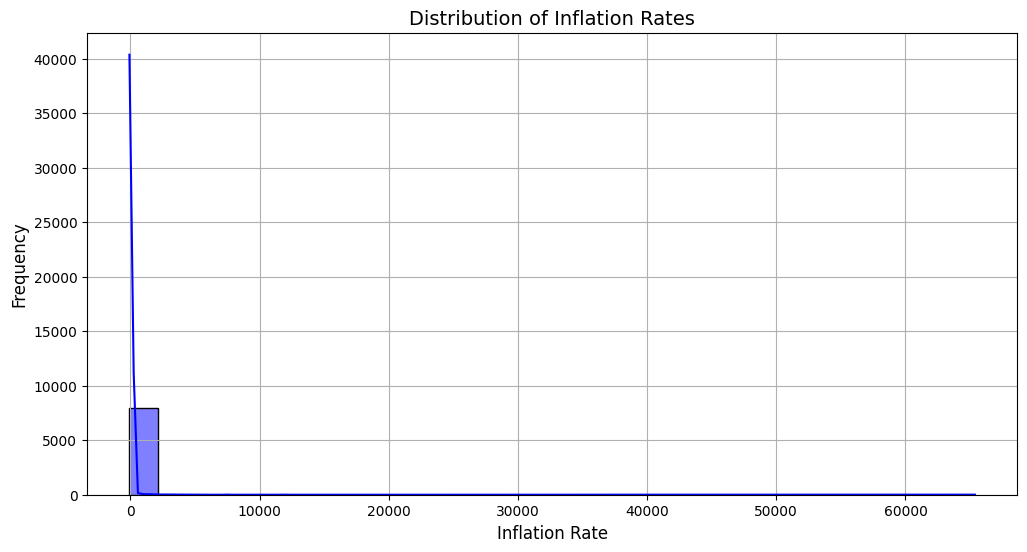

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(inflation['Inflation_Rate'], bins=30, kde=True, color='blue')
plt.title('Distribution of Inflation Rates', fontsize=14)
plt.xlabel('Inflation Rate', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()

The plot indicates the inflation rate distribution with the bars  indicating various intervals of the inflation rates and the bar height indicating the number of data points falling in each interval. Over the histogram, superimposed is the smooth line  to provide a better sense of the overall distribution and indicate where the inflation rates are most dense.

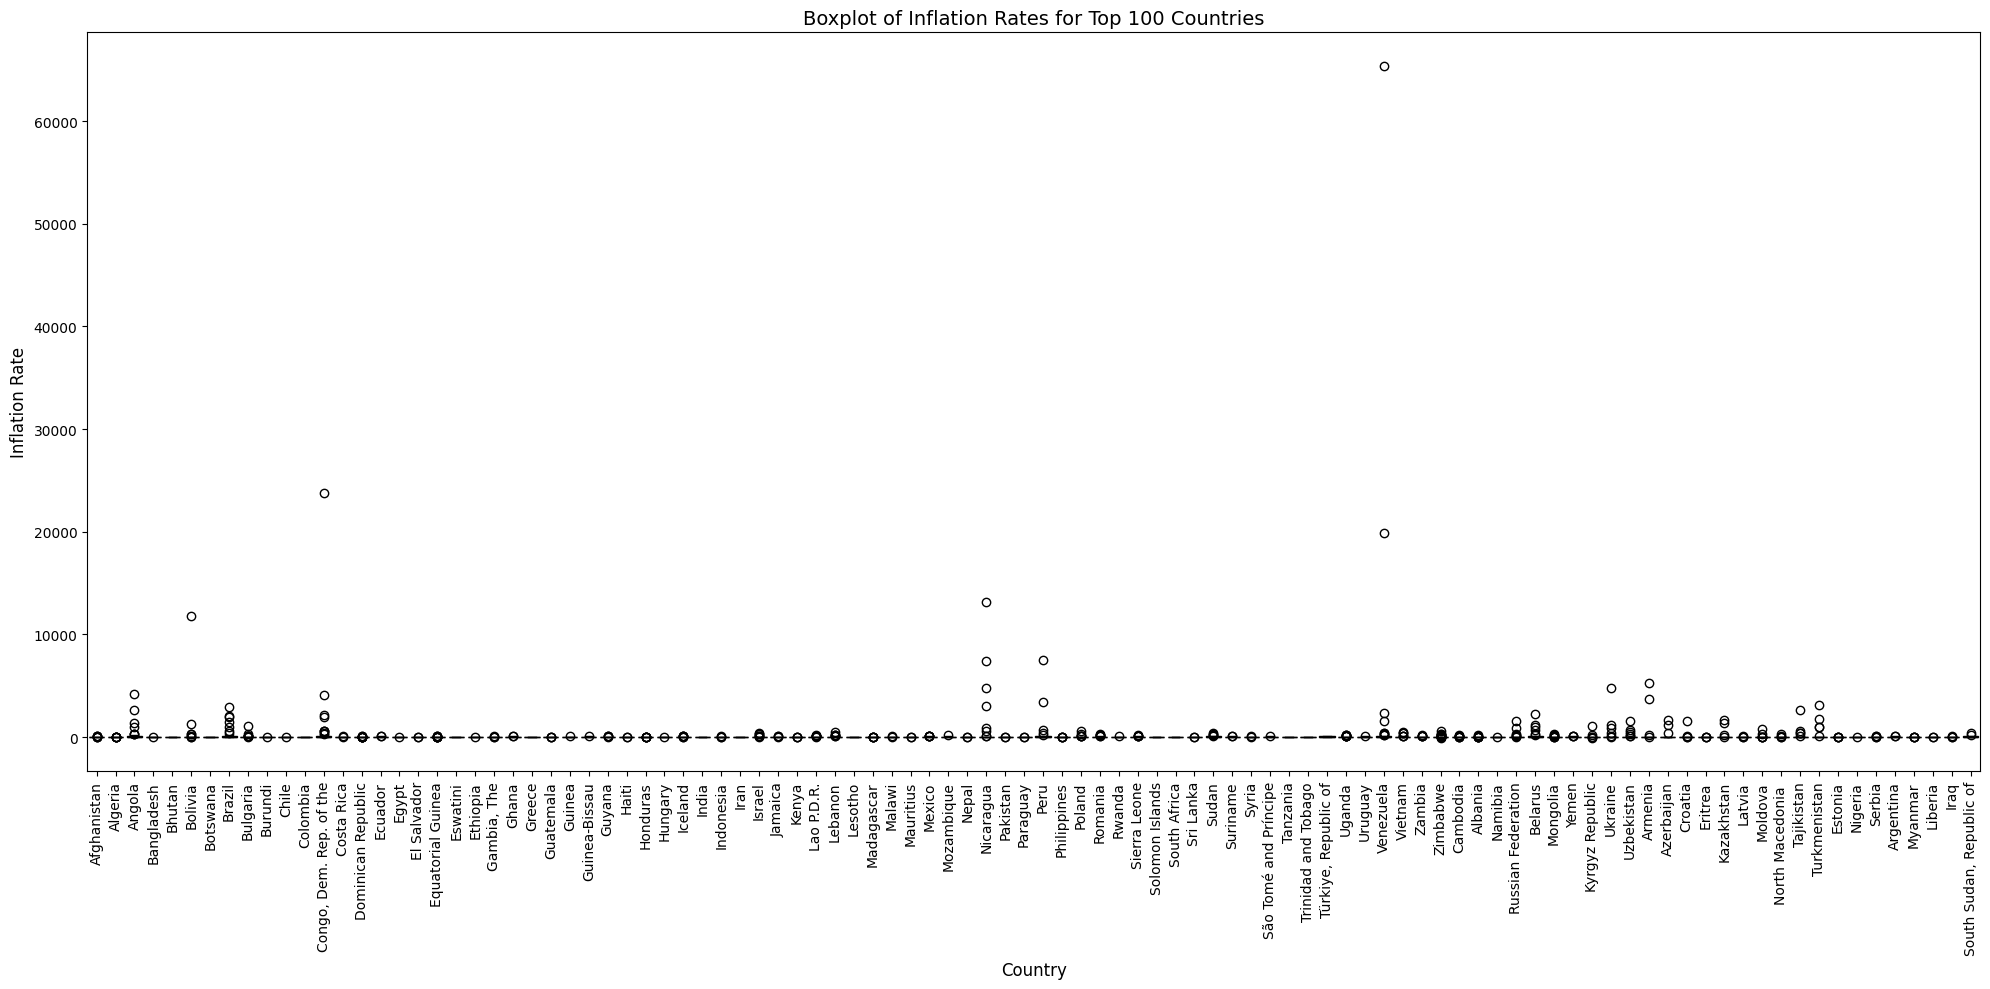

In [ ]:





country_avg_inflation = inflation.groupby('country_name')['Inflation_Rate'].mean().reset_index()
top_100_countries = country_avg_inflation.nlargest(100, 'Inflation_Rate')['country_name'].tolist()
filtered_inflation = inflation[inflation['country_name'].isin(top_100_countries)]
plt.figure(figsize=(20, 10))
box_plot = sns.boxplot(x='country_name', y='Inflation_Rate', data=filtered_inflation,
                       color='black', patch_artist=True)


for box in box_plot.artists:
    box.set_facecolor('grey')
    box.set_edgecolor('black')




plt.title('Boxplot of Inflation Rates for Top 100 Countries', fontsize=14)
plt.ylabel('Inflation Rate', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.tight_layout()
plt.show()

The boxplot below displays the inflation rate for the top 100 nations with the highest relative inflation rate. The grey boxes with black border lines show the spread of the top 100 nations' inflation rates. Each box displays the median, interquartile range (IQR), and outliers. The x-axis displays the nations, while the y-axis displays the inflation rate. The boxplot displays variability and trends in the top 100 nations' inflation rates.


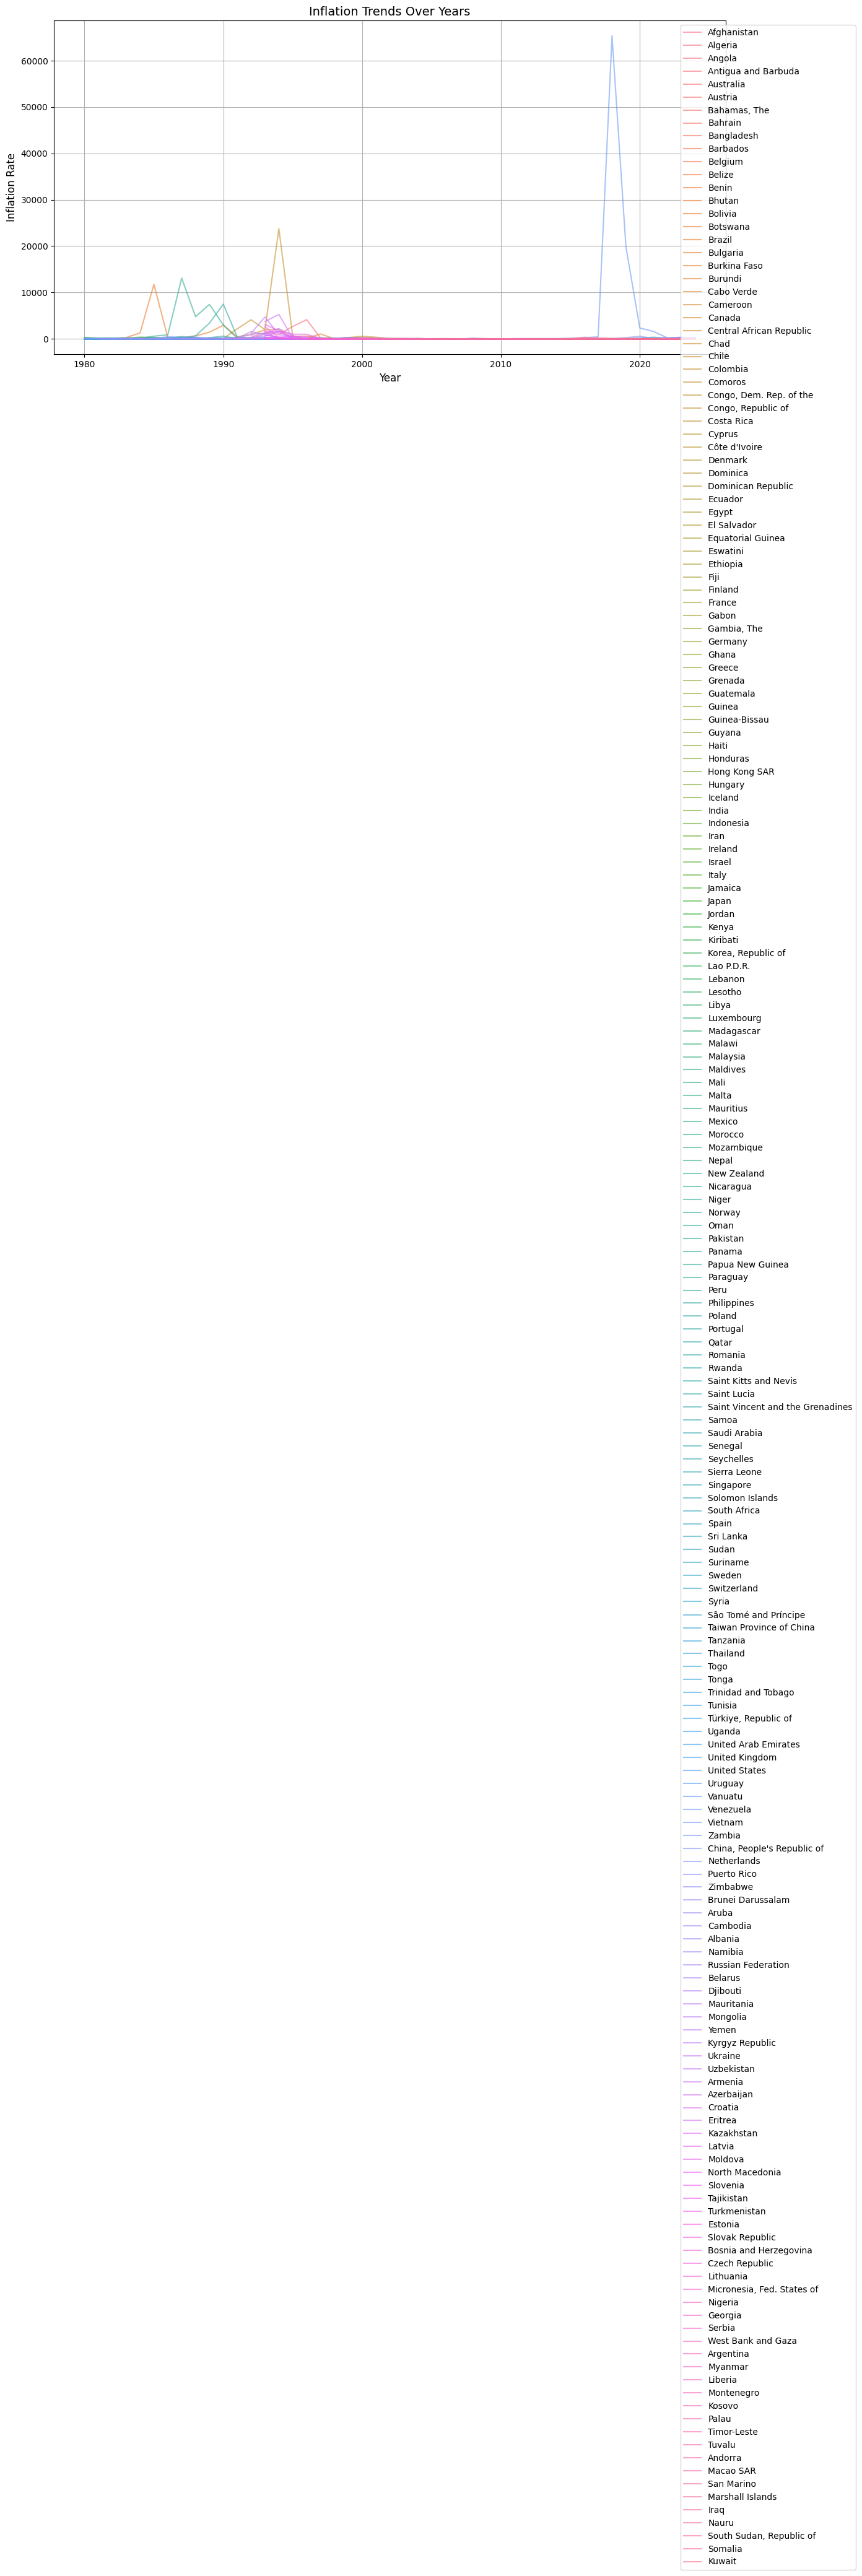

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Year', y='Inflation_Rate', hue='country_name', data=inflation, alpha=0.6)
plt.title('Inflation Trends Over Years', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Inflation Rate', fontsize=12)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
plt.grid(True)
plt.show()

The line chart illustrates the way the inflation rates have evolved over the years for different countries. Years are given in the x-axis, and the inflation rates are given in the y-axis. Each country has its own line, making comparison of the inflation trends for all the countries easy.

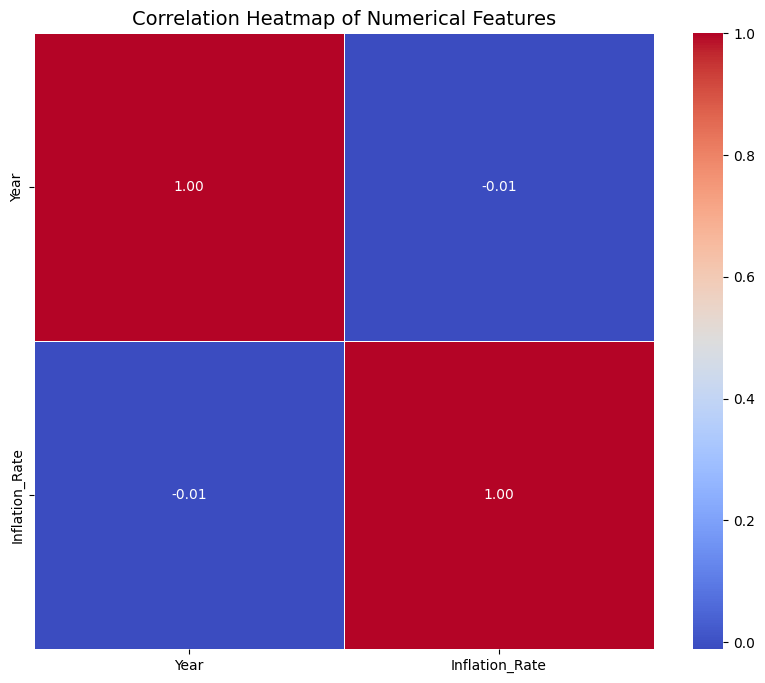

In [ ]:
plt.figure(figsize=(10, 8))
numerical_features = inflation.select_dtypes(include=['number'])
sns.heatmap(numerical_features.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()


correlation heatmap presents the correlation coefficient between pairs of the numeric features. A strong positive relation exists when the correlation coefficient is close to 1, and when close to -1, it indicates a strong negative relation.

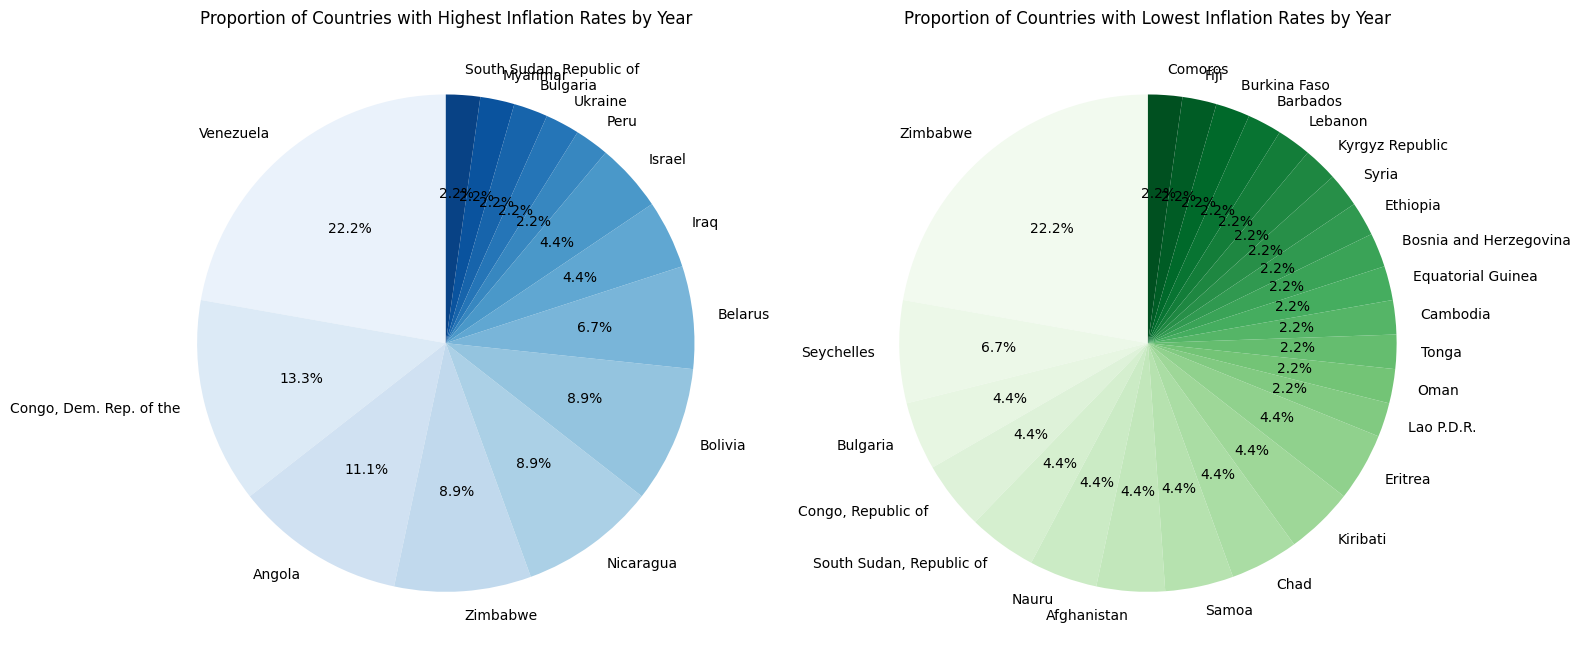

In [ ]:



highest_inflation = inflation.loc[inflation.groupby('Year')['Inflation_Rate'].idxmax()]
lowest_inflation = inflation.loc[inflation.groupby('Year')['Inflation_Rate'].idxmin()]
highest_inflation_count = highest_inflation['country_name'].value_counts()
lowest_inflation_count = lowest_inflation['country_name'].value_counts()


fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].pie(highest_inflation_count, labels=highest_inflation_count.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Blues", len(highest_inflation_count)))
ax[0].set_title('Proportion of Countries with Highest Inflation Rates by Year')

ax[1].pie(lowest_inflation_count, labels=lowest_inflation_count.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Greens", len(lowest_inflation_count)))
ax[1].set_title('Proportion of Countries with Lowest Inflation Rates by Year')


plt.tight_layout()
plt.show()






These two pie charts to show the countries with the highest and the lowest inflation rates over the years. First, it picks the country with the maximum inflation rate for every year and counts the total number of times each country occurs.

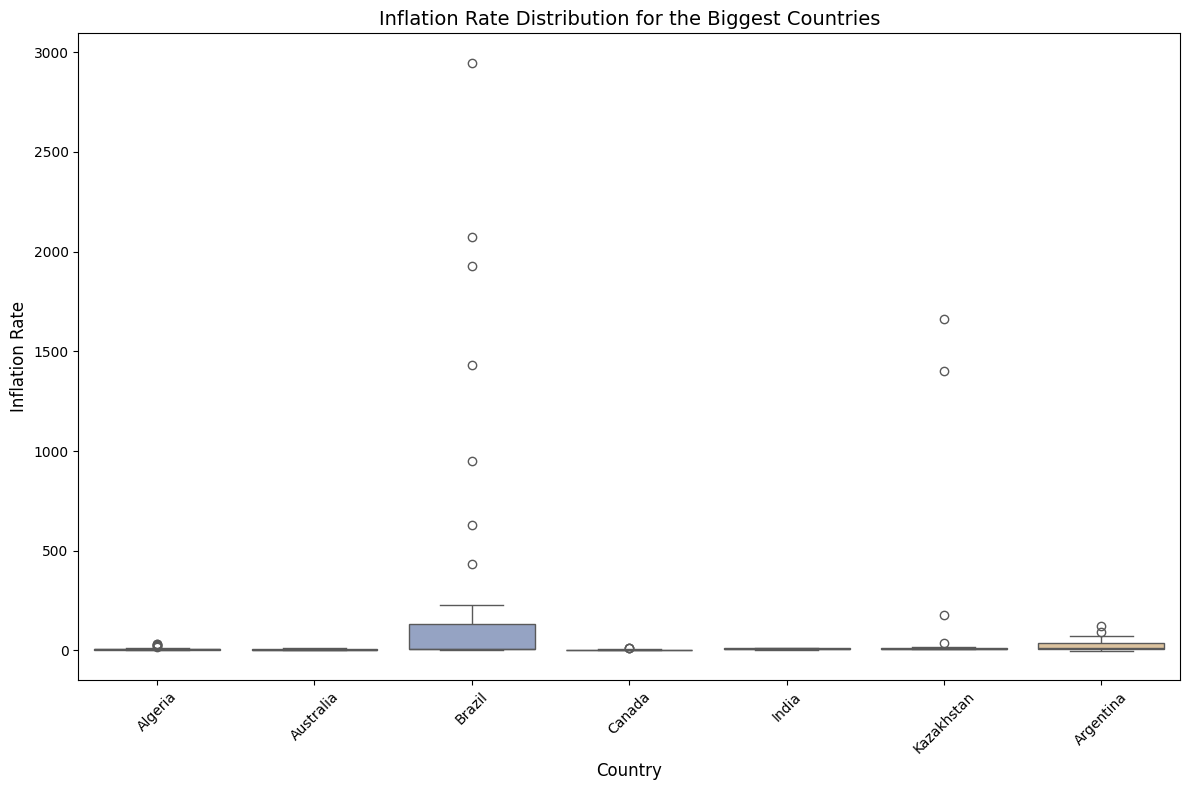

In [ ]:





plt.figure(figsize=(12, 8))


sns.boxplot(data=biggest_inflation, x='country_name', y='Inflation_Rate',
            hue='country_name', palette='Set2', legend=False)

plt.title('Inflation Rate Distribution for the Biggest Countries', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Inflation Rate', fontsize=12)
plt.xticks(rotation=45)
plt.title('Inflation Rate Distribution for the Biggest Countries', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Inflation Rate', fontsize=12)
plt.xticks(rotation=45)


plt.tight_layout()
plt.show()



This Boxplot grapgh indicates the biggest countries inflation rates. , the  brazil has the gratest inflation rates   comapre to other big countries.

**Conclusion**

This analysis provided excellent insights into global inflation trends by looking across several years' worth of inflation rates for many nations. Through data processing, we removed the unnecessary columns from the dataset and imputed the missing values. Through the use of scatter plots and line plots, we compared inflation rates to find the outliers and track the way the inflation rates varied across the years. Through the analysis, the countries with the highest and lowest inflation rates for each year were discovered, making it simpler to interpret inflationary trends across the globe. Through the use of pie charts, the distribution of the countries with the highest and lowest inflation were also visualized, showing the proportion of the number of times the inflation rate of each country occurred. Overall, this assignment did an excellent job of showing global differences in inflation and aiding in the finding of significant trends, outliers, and patterns in inflation across nations and years.